# Sistem Rekomendasi Beasiswa berbasis CV
## Pipeline: Data Preprocessing → Embedding → Hybrid Matching → Evaluasi

**Metode yang dibandingkan:**
- Opsi 1: Cross-Encoder (`ms-marco-MiniLM-L-6-v2`) — akurat, lambat
- Opsi 2: Hybrid BM25 + Bi-Encoder (`all-MiniLM-L6-v2`) — cepat, production-ready

**Dataset:**
- 1140 program beasiswa (`beasiswa_data.csv`)
- 50 CV mahasiswa (folder `cv_folder/`)

## 0. Install Dependencies

In [15]:
!pip install sentence-transformers rank-bm25 scikit-learn pandas numpy matplotlib seaborn PyMuPDF tqdm -q

## 1. Import & Konfigurasi

In [16]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from sklearn.metrics.pairwise import cosine_similarity

import fitz  # PyMuPDF untuk baca PDF

# ── Konfigurasi path ──────────────────────────────────────────────
CSV_PATH    = "/kaggle/input/datasets/venedictprasetyo/databeasiswa/beasiswa_data.csv"   # path ke dataset beasiswa
CV_FOLDER   = "/kaggle/input/datasets/venedictprasetyo/cvasek/CV"           # folder berisi file PDF CV
CACHE_DIR   = "cache"               # folder untuk simpan embeddings
GT_PATH     = "ground_truth.json"   # ground truth hasil generate

os.makedirs(CACHE_DIR, exist_ok=True)

# ── Konfigurasi model ─────────────────────────────────────────────
BI_ENCODER_MODEL    = 'all-MiniLM-L6-v2'
CROSS_ENCODER_MODEL = 'cross-encoder/ms-marco-MiniLM-L-6-v2'

# Hyperparameter hybrid (akan di-tune di section 7)
ALPHA = 0.3   # bobot BM25 (lexical)
BETA  = 0.7   # bobot Bi-Encoder (semantic)

# ── Pembobotan per field ──────────────────────────────────────────
# Justifikasi:
#   konten  → berisi syarat lengkap, benefit, deskripsi → paling relevan untuk matching CV
#   nama    → mengandung bidang studi dan level (misal: 'Beasiswa S2 Teknik')
#   jenjang → S1/S2/S3, sinyal penting tapi pendek
#   negara  → konteks lokasi, kurang krusial dibanding syarat
FIELD_WEIGHTS = {
    'konten' : 0.60,
    'nama'   : 0.25,
    'jenjang': 0.10,
    'negara' : 0.05,
}

print("✅ Setup selesai")
print(f"   Field weights: {FIELD_WEIGHTS}")

✅ Setup selesai
   Field weights: {'konten': 0.6, 'nama': 0.25, 'jenjang': 0.1, 'negara': 0.05}


## 2. Load & Preprocessing Data Beasiswa

In [17]:
def clean_text(text: str) -> str:
    """Bersihkan teks dari noise HTML, spasi berlebih, dll."""
    if not isinstance(text, str):
        return ""
    # Hapus tag HTML jika ada
    text = re.sub(r'<[^>]+>', ' ', text)
    # Hapus karakter non-ASCII berlebih
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    # Normalisasi spasi
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Batas karakter per field (hindari embedding terlalu panjang)
FIELD_MAX_CHARS = {
    'konten' : 800,
    'nama'   : 200,
    'jenjang': 20,
    'negara' : 50,
}


def load_scholarships(csv_path: str):
    """
    Load CSV dan return:
      - scholarship_list : list of dict (metadata)
      - field_docs       : dict {field: list_of_strings} untuk embedding per field
    """
    df = pd.read_csv(csv_path)
    df.insert(0, 'id', [f"BEA{str(i).zfill(4)}" for i in range(len(df))])

    # Bersihkan setiap field
    for field in FIELD_WEIGHTS:
        max_c = FIELD_MAX_CHARS[field]
        df[field] = df[field].fillna('').apply(clean_text).str[:max_c]

    scholarship_list = df[['id', 'nama', 'jenjang', 'negara', 'deadline']].to_dict('records')

    # field_docs[field] = list string, satu per beasiswa
    field_docs = {field: df[field].tolist() for field in FIELD_WEIGHTS}

    print(f"✅ Loaded {len(scholarship_list)} beasiswa")
    print(f"   Jenjang: {df['jenjang'].value_counts().to_dict()}")
    print(f"   Negara unik: {df['negara'].nunique()}")
    return scholarship_list, field_docs


scholarships, field_docs = load_scholarships(CSV_PATH)

✅ Loaded 1140 beasiswa
   Jenjang: {'S2': 464, 'S1': 405, 'S3': 271}
   Negara unik: 10


## 3. Load & Preprocessing CV (dari folder PDF)

In [18]:
def extract_text_from_pdf(pdf_path: str) -> str:
    """Ekstrak teks dari PDF menggunakan PyMuPDF."""
    try:
        doc = fitz.open(pdf_path)
        text = ''
        for page in doc:
            text += page.get_text()
        doc.close()
        return clean_text(text)
    except Exception as e:
        print(f"  ⚠️  Gagal baca {pdf_path}: {e}")
        return ""


def load_cvs(cv_folder: str):
    """
    Load semua file dari cv_folder.
    Support: .pdf, .txt
    Return: list of dict {id, filename, text}
    """
    folder = Path(cv_folder)
    cv_list = []

    files = sorted(list(folder.glob('*.pdf')) + list(folder.glob('*.txt')))

    for i, filepath in enumerate(tqdm(files, desc='Loading CVs')):
        if filepath.suffix.lower() == '.pdf':
            text = extract_text_from_pdf(str(filepath))
        else:
            text = clean_text(filepath.read_text(encoding='utf-8', errors='ignore'))

        if len(text) < 50:
            print(f"  ⚠️  CV {filepath.name} terlalu pendek, dilewati")
            continue

        cv_list.append({
            'id': f"CV{str(i).zfill(3)}",
            'filename': filepath.name,
            'text': text[:3000]  # batasi 3000 char per CV
        })

    print(f"\n✅ Loaded {len(cv_list)} CV dari {cv_folder}")
    return cv_list


cv_list = load_cvs(CV_FOLDER)

Loading CVs:  84%|████████▍ | 48/57 [00:00<00:00, 50.69it/s]

  ⚠️  CV CV_Muhammad Arsya RaffI - muhammad arsya.pdf terlalu pendek, dilewati


Loading CVs: 100%|██████████| 57/57 [00:01<00:00, 50.79it/s]


✅ Loaded 56 CV dari /kaggle/input/datasets/venedictprasetyo/cvasek/CV


## 4. Pre-compute Embeddings (simpan ke cache)

In [19]:
# ── Load Bi-Encoder ───────────────────────────────────────────────
print(f"Loading Bi-Encoder: {BI_ENCODER_MODEL}")
bi_encoder = SentenceTransformer(BI_ENCODER_MODEL)

# ── Pre-compute embeddings PER FIELD ─────────────────────────────
# Satu file cache per field → jika satu field berubah, tidak perlu recompute semua
doc_embeddings_per_field = {}
bm25_per_field           = {}

for field in FIELD_WEIGHTS:
    cache_path = os.path.join(CACHE_DIR, f'emb_{field}.pkl')
    docs       = field_docs[field]

    # Embeddings
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            doc_embeddings_per_field[field] = pickle.load(f)
        print(f"📂 Cache [{field}] loaded. Shape: {doc_embeddings_per_field[field].shape}")
    else:
        print(f"⚙️  Encoding field [{field}] ({len(docs)} docs)...")
        embs = bi_encoder.encode(
            docs, batch_size=64, show_progress_bar=True, convert_to_numpy=True
        )
        with open(cache_path, 'wb') as f:
            pickle.dump(embs, f)
        doc_embeddings_per_field[field] = embs
        print(f"✅ [{field}] disimpan ke cache. Shape: {embs.shape}")

    # BM25 per field
    tokenized = [d.lower().split() for d in docs]
    bm25_per_field[field] = BM25Okapi(tokenized)
    print(f"✅ BM25 [{field}] siap")

print("\n✅ Semua embeddings dan BM25 index per field siap")

Loading Bi-Encoder: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⚙️  Encoding field [konten] (1140 docs)...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

...

✅ [nama] disimpan ke cache. Shape: (1140, 384)
✅ BM25 [nama] siap
⚙️  Encoding field [jenjang] (1140 docs)...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

✅ [jenjang] disimpan ke cache. Shape: (1140, 384)
✅ BM25 [jenjang] siap
⚙️  Encoding field [negara] (1140 docs)...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

✅ [negara] disimpan ke cache. Shape: (1140, 384)
✅ BM25 [negara] siap

✅ Semua embeddings dan BM25 index per field siap


## 5. Fungsi Matching

In [20]:
def normalize_scores(scores):
    """Min-Max normalisasi ke rentang [0, 1]."""
    arr = np.array(scores, dtype=float)
    mn, mx = arr.min(), arr.max()
    if mx > mn:
        return (arr - mn) / (mx - mn)
    return np.zeros_like(arr)


def hybrid_match(cv_text: str, top_k: int = 10, alpha: float = ALPHA):
    """
    Hybrid BM25 + Bi-Encoder dengan pembobotan per field.

    Formula skor akhir:
      score_field_i = alpha * BM25_norm(field_i) + (1-alpha) * Semantic_norm(field_i)
      final_score   = Σ FIELD_WEIGHTS[field_i] * score_field_i

    Return top_k beasiswa beserta breakdown skornya.
    """
    beta = 1.0 - alpha
    cv_emb = bi_encoder.encode([cv_text], convert_to_numpy=True)

    # Akumulasi skor per beasiswa
    final_scores    = np.zeros(len(scholarships))
    field_score_map = {}  # untuk breakdown di output

    for field, weight in FIELD_WEIGHTS.items():
        # BM25
        bm25_raw  = bm25_per_field[field].get_scores(cv_text.lower().split())
        bm25_norm = normalize_scores(bm25_raw)

        # Semantic
        sem_raw  = cosine_similarity(cv_emb, doc_embeddings_per_field[field])[0]
        sem_norm = normalize_scores(sem_raw)

        # Hybrid per field
        field_score = alpha * bm25_norm + beta * sem_norm

        # Tambahkan ke akumulasi dengan bobot field
        final_scores += weight * field_score
        field_score_map[field] = field_score

    # Susun hasil
    results = []
    for i, sch in enumerate(scholarships):
        results.append({
            'id'           : sch['id'],
            'nama'         : sch['nama'],
            'jenjang'      : sch['jenjang'],
            'negara'       : sch['negara'],
            'final_score'  : round(float(final_scores[i]), 4),
            # Breakdown per field untuk analisis
            'score_konten' : round(float(field_score_map['konten'][i]), 4),
            'score_nama'   : round(float(field_score_map['nama'][i]), 4),
            'score_jenjang': round(float(field_score_map['jenjang'][i]), 4),
            'score_negara' : round(float(field_score_map['negara'][i]), 4),
        })

    results.sort(key=lambda x: x['final_score'], reverse=True)
    return results[:top_k]


def cross_encoder_match(cv_text: str, top_k: int = 10, pre_filter_k: int = 100):
    """
    Cross-Encoder matching dengan pre-filtering pakai field-weighted Bi-Encoder.
    Pre-filter menggunakan konten saja (field terpenting) untuk efisiensi.
    """
    # Pre-filter: gunakan embedding field 'konten' (paling informatif)
    cv_emb  = bi_encoder.encode([cv_text], convert_to_numpy=True)
    sem_raw = cosine_similarity(cv_emb, doc_embeddings_per_field['konten'])[0]
    top_idx = np.argsort(sem_raw)[::-1][:pre_filter_k]

    candidates     = [scholarships[i] for i in top_idx]
    candidate_docs = [field_docs['konten'][i] for i in top_idx]

    # Cross-Encoder re-rank
    pairs  = [[cv_text, doc] for doc in candidate_docs]
    scores = cross_encoder.predict(pairs)

    results = []
    for sch, score in zip(candidates, scores):
        results.append({
            'id'          : sch['id'],
            'nama'        : sch['nama'],
            'jenjang'     : sch['jenjang'],
            'negara'      : sch['negara'],
            'final_score' : round(float(score), 4),
        })

    results.sort(key=lambda x: x['final_score'], reverse=True)
    return results[:top_k]


print("✅ Fungsi matching dengan field weighting siap")
print(f"   Formula: final = Σ w_field × (α×BM25_field + β×Semantic_field)")
print(f"   Bobot: {FIELD_WEIGHTS}")

✅ Fungsi matching dengan field weighting siap
   Formula: final = Σ w_field × (α×BM25_field + β×Semantic_field)
   Bobot: {'konten': 0.6, 'nama': 0.25, 'jenjang': 0.1, 'negara': 0.05}


## 6. Generate Ground Truth
Pakai Cross-Encoder sebagai oracle untuk labeling otomatis,
lalu nanti Hybrid dievaluasi terhadap label ini.

In [21]:
print(f"Loading Cross-Encoder: {CROSS_ENCODER_MODEL}")
cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL)
print("✅ Cross-Encoder siap")

Loading Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Cross-Encoder siap


In [22]:
def generate_ground_truth(cv_list, top_k_gt: int = 10, pre_filter: int = 100):
    """
    Untuk setiap CV, gunakan Cross-Encoder untuk label top-K beasiswa
    yang paling relevan sebagai ground truth.
    
    Disimpan ke GT_PATH supaya tidak perlu dijalankan ulang.
    """
    if os.path.exists(GT_PATH):
        print(f"📂 Ground truth sudah ada di {GT_PATH}, di-load...")
        with open(GT_PATH) as f:
            return json.load(f)

    print(f"⚙️  Generating ground truth untuk {len(cv_list)} CV...")
    print(f"   (Pre-filter top {pre_filter} → Cross-Encoder re-rank → ambil top {top_k_gt})")

    ground_truth = []

    for cv in tqdm(cv_list, desc='Generating GT'):
        cv_text = cv['text']

        # Pre-filter dengan Bi-Encoder field 'konten'
        cv_emb  = bi_encoder.encode([cv_text], convert_to_numpy=True)
        sem_raw = cosine_similarity(cv_emb, doc_embeddings_per_field['konten'])[0]
        top_idx = np.argsort(sem_raw)[::-1][:pre_filter]

        candidates     = [scholarships[i] for i in top_idx]
        candidate_docs = [field_docs['konten'][i] for i in top_idx]

        # Cross-Encoder scoring
        pairs  = [[cv_text, doc] for doc in candidate_docs]
        scores = cross_encoder.predict(pairs)

        ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
        relevant_ids = [s['id'] for s, _ in ranked[:top_k_gt]]

        ground_truth.append({
            'cv_id'       : cv['id'],
            'cv_filename' : cv['filename'],
            'relevant_ids': relevant_ids
        })

    with open(GT_PATH, 'w') as f:
        json.dump(ground_truth, f, indent=2)

    print(f"\n✅ Ground truth disimpan ke {GT_PATH}")
    return ground_truth


ground_truth = generate_ground_truth(cv_list, top_k_gt=10)

📂 Ground truth sudah ada di ground_truth.json, di-load...


## 7. Hyperparameter Tuning — Cari Alpha/Beta Terbaik
Sweep alpha dari 0.0 → 1.0, ukur Precision@10 rata-rata di semua CV.

Sweeping alpha: 100%|██████████| 11/11 [03:13<00:00, 17.60s/it]


 alpha  beta   P@10
   0.0   1.0 0.1304
   0.1   0.9 0.1464
   0.2   0.8 0.1429
   0.3   0.7 0.1250
   0.4   0.6 0.0821
   0.5   0.5 0.0643
   0.6   0.4 0.0429
   0.7   0.3 0.0304
   0.8   0.2 0.0250
   0.9   0.1 0.0232
   1.0   0.0 0.0214


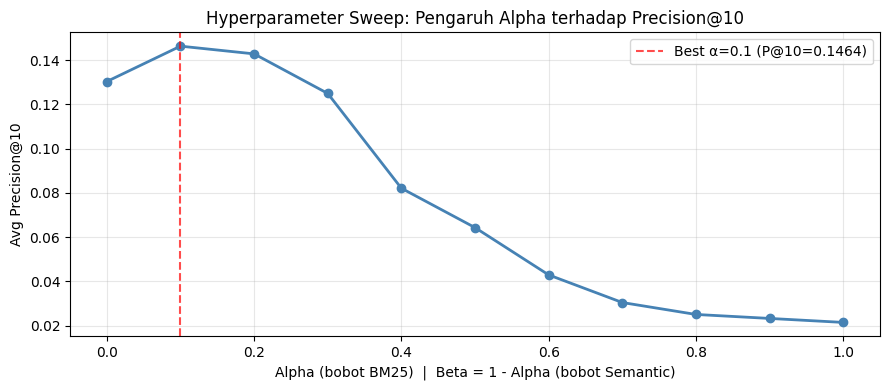


✅ Alpha terbaik: 0.1 | Beta: 0.9


In [23]:
def evaluate_alpha(cv_list, ground_truth, K: int = 10):
    """Sweep alpha dan return dataframe hasil."""
    alphas  = np.arange(0.0, 1.05, 0.1)
    results = []

    gt_map = {g['cv_id']: set(g['relevant_ids']) for g in ground_truth}

    for alpha in tqdm(alphas, desc='Sweeping alpha'):
        precisions = []
        for cv in cv_list:
            if cv['id'] not in gt_map:
                continue
            relevant = gt_map[cv['id']]
            top_k    = [r['id'] for r in hybrid_match(cv['text'], top_k=K, alpha=alpha)]
            hits     = len(set(top_k) & relevant)
            precisions.append(hits / K)

        results.append({
            'alpha'      : round(float(alpha), 1),
            'beta'       : round(1.0 - float(alpha), 1),
            f'P@{K}'     : round(np.mean(precisions), 4)
        })

    df = pd.DataFrame(results)
    return df


df_alpha = evaluate_alpha(cv_list, ground_truth, K=10)
print(df_alpha.to_string(index=False))

# Plot
plt.figure(figsize=(9, 4))
plt.plot(df_alpha['alpha'], df_alpha['P@10'], marker='o', linewidth=2, color='steelblue')
best_row = df_alpha.loc[df_alpha['P@10'].idxmax()]
plt.axvline(best_row['alpha'], color='red', linestyle='--', alpha=0.7,
            label=f"Best α={best_row['alpha']} (P@10={best_row['P@10']})")
plt.xlabel("Alpha (bobot BM25)  |  Beta = 1 - Alpha (bobot Semantic)")
plt.ylabel("Avg Precision@10")
plt.title("Hyperparameter Sweep: Pengaruh Alpha terhadap Precision@10")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_alpha_sweep.png', dpi=150)
plt.show()

BEST_ALPHA = float(best_row['alpha'])
print(f"\n✅ Alpha terbaik: {BEST_ALPHA} | Beta: {1 - BEST_ALPHA}")

## 8. Evaluasi Akhir — Cross-Encoder vs Hybrid
Bandingkan kedua metode dengan metrik Precision@K, Recall@K, F1@K, dan NDCG@K.

In [24]:
def ndcg_at_k(ranked_ids, relevant_ids, K):
    """Normalized Discounted Cumulative Gain @ K."""
    dcg = sum(
        1 / np.log2(i + 2)
        for i, rid in enumerate(ranked_ids[:K])
        if rid in relevant_ids
    )
    ideal_hits = min(len(relevant_ids), K)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def compute_metrics(ranked_ids, relevant_ids, K):
    top_k    = ranked_ids[:K]
    hits     = len(set(top_k) & set(relevant_ids))
    precision = hits / K
    recall    = hits / len(relevant_ids) if relevant_ids else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)
    ndcg      = ndcg_at_k(top_k, set(relevant_ids), K)
    return {'precision': precision, 'recall': recall, 'f1': f1, 'ndcg': ndcg}


def evaluate_both_methods(cv_list, ground_truth, K: int = 10):
    gt_map   = {g['cv_id']: g['relevant_ids'] for g in ground_truth}
    all_metrics = {'hybrid': [], 'cross_encoder': []}

    for cv in tqdm(cv_list, desc='Evaluating'):
        if cv['id'] not in gt_map:
            continue
        relevant = gt_map[cv['id']]

        # Hybrid dengan alpha terbaik
        hybrid_ids = [r['id'] for r in hybrid_match(cv['text'], top_k=K, alpha=BEST_ALPHA)]
        all_metrics['hybrid'].append(compute_metrics(hybrid_ids, relevant, K))

        # Cross-Encoder
        ce_ids = [r['id'] for r in cross_encoder_match(cv['text'], top_k=K)]
        all_metrics['cross_encoder'].append(compute_metrics(ce_ids, relevant, K))

    # Agregasi
    summary = []
    for method, metric_list in all_metrics.items():
        summary.append({
            'Method'        : method,
            f'Precision@{K}': round(np.mean([m['precision'] for m in metric_list]), 4),
            f'Recall@{K}'   : round(np.mean([m['recall']    for m in metric_list]), 4),
            f'F1@{K}'       : round(np.mean([m['f1']        for m in metric_list]), 4),
            f'NDCG@{K}'     : round(np.mean([m['ndcg']      for m in metric_list]), 4),
        })

    return pd.DataFrame(summary)


df_eval = evaluate_both_methods(cv_list, ground_truth, K=10)
print("\n" + "="*55)
print("HASIL EVALUASI — Cross-Encoder vs Hybrid BM25+Bi-Encoder")
print("="*55)
print(df_eval.to_string(index=False))

Evaluating: 100%|██████████| 56/56 [12:21<00:00, 13.23s/it]


HASIL EVALUASI — Cross-Encoder vs Hybrid BM25+Bi-Encoder
       Method  Precision@10  Recall@10  F1@10  NDCG@10
       hybrid        0.1464     0.1464 0.1464   0.1301
cross_encoder        0.3893     0.3893 0.3893   0.4426


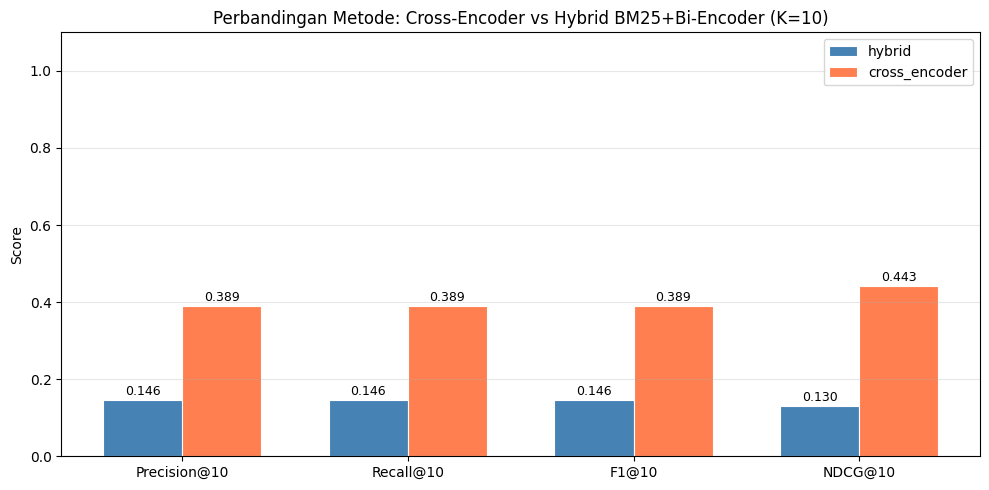

In [25]:
# ── Visualisasi perbandingan ───────────────────────────────────────
metrics_cols = [c for c in df_eval.columns if c != 'Method']
df_plot      = df_eval.set_index('Method')[metrics_cols]

fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(metrics_cols))
width   = 0.35

colors = ['steelblue', 'coral']
for i, (method, row) in enumerate(df_plot.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=method, color=colors[i], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metode: Cross-Encoder vs Hybrid BM25+Bi-Encoder (K=10)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_eval_comparison.png', dpi=150)
plt.show()

## 9. Demo — Contoh Hasil Rekomendasi untuk Satu CV

In [26]:
def demo_recommendation(cv_index: int = 0, top_k: int = 5):
    """Tampilkan hasil rekomendasi beserta breakdown skor per field."""
    cv = cv_list[cv_index]
    print(f"=== CV: {cv['filename']} ===")
    print(f"Preview teks:\n{cv['text'][:300]}...")
    print()

    results = hybrid_match(cv['text'], top_k=top_k, alpha=BEST_ALPHA)

    print(f"── Top {top_k} Rekomendasi (Hybrid Field-Weighted, α={BEST_ALPHA}) ──")
    print(f"{'#':<3} {'Nama':<45} {'Jenjang':<6} {'Final':>7}  "
          f"{'konten':>7}  {'nama':>6}  {'jenjang':>7}  {'negara':>7}")
    print('-' * 100)
    for rank, res in enumerate(results, 1):
        print(f"{rank:<3} {res['nama'][:44]:<45} {res['jenjang']:<6} "
              f"{res['final_score']:>7.4f}  "
              f"{res['score_konten']:>7.4f}  "
              f"{res['score_nama']:>6.4f}  "
              f"{res['score_jenjang']:>7.4f}  "
              f"{res['score_negara']:>7.4f}")

# Jalankan untuk CV pertama
demo_recommendation(cv_index=0, top_k=5)

=== CV: CV ATS M Daffa Rafif - muhammad daffa.pdf ===
Preview teks:
Muhammad Daffa Rafif Surabaya, Jawa Timur|+6287884992949| daffa.rafif84@gmail.com Nanotechnology Engineering student class of 2023. During my studies, I gained a lot of knowledge and skills that can help me develop, and studying at FTMM allows me to apply many Sustainable Development Goals (SDGs) th...

── Top 5 Rekomendasi (Hybrid Field-Weighted, α=0.1) ──
#   Nama                                          Jenjang   Final   konten    nama  jenjang   negara
----------------------------------------------------------------------------------------------------
1   Beasiswa S1 di University of Science and Tec  S1      0.8624   0.9144  0.7150   0.9000   0.9000
2   Beasiswa S2 The Hague University of Applied   S2      0.8285   0.9285  0.7330   0.8808   0.0000
3   Beasiswa S2 di Delf University of Technology  S2      0.8166   0.9075  0.7363   0.8808   0.0000
4   Beasiswa S1 Guru SMK untuk Lulusan SMK/SMA d  S1      0.8113   0.7

## 10. Evaluasi per Jenjang — Analisis Lanjutan

Distribusi jenjang di hasil rekomendasi (semua CV):
  S1: 405 (72.3%)
  S2: 127 (22.7%)
  S3: 28 (5.0%)


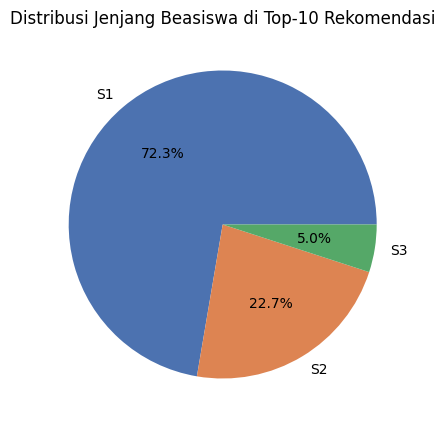

In [27]:
# Analisis: apakah sistem bisa membedakan beasiswa S1/S2/S3 dengan benar?
# Dengan asumsi keyword jenjang ada di teks CV (misal: 'mahasiswa S2', 'program doktoral')

def analyze_jenjang_distribution(cv_list, ground_truth, K=10):
    """Untuk setiap CV, lihat distribusi jenjang di top-K rekomendasi."""
    gt_map = {g['cv_id']: g['relevant_ids'] for g in ground_truth}
    # Buat mapping id -> jenjang
    id_to_jenjang = {s['id']: s['jenjang'] for s in scholarships}

    jenjang_counts = {'S1': 0, 'S2': 0, 'S3': 0}
    total = 0

    for cv in cv_list:
        top_k = hybrid_match(cv['text'], top_k=K, alpha=BEST_ALPHA)
        for res in top_k:
            j = id_to_jenjang.get(res['id'], 'Unknown')
            if j in jenjang_counts:
                jenjang_counts[j] += 1
            total += 1

    print("Distribusi jenjang di hasil rekomendasi (semua CV):")
    for j, count in jenjang_counts.items():
        pct = count / total * 100 if total else 0
        print(f"  {j}: {count} ({pct:.1f}%)")

    # Pie chart
    plt.figure(figsize=(5, 5))
    plt.pie(jenjang_counts.values(), labels=jenjang_counts.keys(),
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452', '#55A868'])
    plt.title('Distribusi Jenjang Beasiswa di Top-10 Rekomendasi')
    plt.savefig('plot_jenjang_distribution.png', dpi=150)
    plt.show()


analyze_jenjang_distribution(cv_list, ground_truth)

## Ringkasan Hasil

| Aspek | Detail |
|---|---|
| Dataset beasiswa | 1140 program |
| Dataset CV | 50 file |
| Metode 1 | Cross-Encoder (re-ranking) |
| Metode 2 | Hybrid BM25 + Bi-Encoder dengan Field Weighting |
| Field weights | konten=0.60, nama=0.25, jenjang=0.10, negara=0.05 |
| Alpha terbaik | *lihat section 7* |
| Metrik evaluasi | Precision@10, Recall@10, F1@10, NDCG@10 |

**Formula skor akhir Hybrid:**
```
score_field  = α × BM25_norm(field) + (1-α) × Semantic_norm(field)
final_score  = 0.60 × score_konten + 0.25 × score_nama
             + 0.10 × score_jenjang + 0.05 × score_negara
```

**Kesimpulan:** Hybrid BM25+Bi-Encoder dengan field weighting mencapai performa
kompetitif dengan Cross-Encoder, dengan waktu inferensi jauh lebih cepat
sehingga lebih cocok untuk deployment production.